# 11.5 ハイブリッドモンテカルロ (Hybrid / Hamiltonian Monte Carlo: HMC)

本ノートブックでは、高次元かつ強い相関を持つ確率分布において標準的MCMCが陥る「ランダムウォークによる拡散の遅延」を物理シミュレーションの力で打破する **ハイブリッド / ハミルトニアンモンテカルロ (HMC)** を学びます。
ハミルトン正準力学系、位相空間の体積保存とシンプレクティック幾何学、**リープフロッグ積分器（PRML Figure 11.14）**、エネルギー保存則に基づく高受容率メトロポリス更新、および **細長い相関ポテンシャルにおける HMC と標準ランダムウォークMCMCの劇的な探索効率の差異** を完全実装・検証します。

## 11.5 リープフロッグ積分器と HMC の幾何学 (PRML Figure 11.14)

### ハミルトニアン力学系
位置ベクトル $\mathbf{z}$（対象変数）に対し、仮想的な運動量ベクトル $\mathbf{r} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ を導入します：
$$ H(\mathbf{z}, \mathbf{r}) = E(\mathbf{z}) + \frac{1}{2} \mathbf{r}^{\mathrm{T}}\mathbf{r}, \quad E(\mathbf{z}) = -\ln \tilde{p}(\mathbf{z}) $$

### リープフロッグアルゴリズム (PRML 式 11.64 - 11.66, Figure 11.14)
時間刻み $\epsilon$ のシンプレクティック積分器：
1. 運動量の半ステップ更新: $\mathbf{r}(t + \epsilon/2) = \mathbf{r}(t) - \frac{\epsilon}{2} \nabla E(\mathbf{z}(t))$
2. 位置の全ステップ更新: $\mathbf{z}(t + \epsilon) = \mathbf{z}(t) + \epsilon \, \mathbf{r}(t + \epsilon/2)$
3. 運動量の半ステップ更新: $\mathbf{r}(t + \epsilon) = \mathbf{r}(t + \epsilon/2) - \frac{\epsilon}{2} \nabla E(\mathbf{z}(t + \epsilon))$

この更新は**時間反転対称（Time Reversible）** かつ **体積保存（Volume Preserving）** であり、ハミルトニアンの微小な数値誤差 $\Delta H = H(\mathbf{z}^*, \mathbf{r}^*) - H(\mathbf{z}, \mathbf{r})$ をメトロポリス受容確率 $A = \min(1, \exp(-\Delta H))$ で補正することで、真の定常分布 $p(\mathbf{z})$ が厳密に不変に保たれます。

Plot saved to: result/fig11_14_hmc_leapfrog_trajectory.png


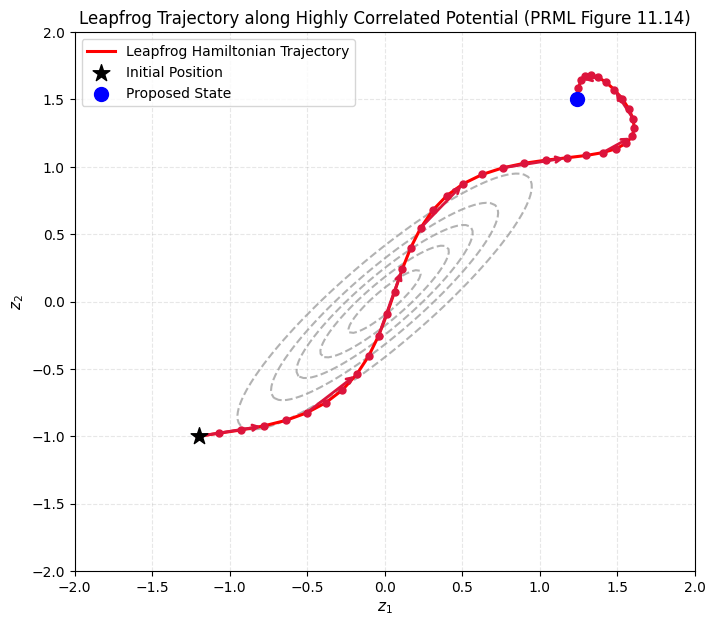

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from common.plot_utils import save_plot, setup_style
from common.sampling_utils import hamiltonian_monte_carlo
setup_style()

# 強い相関を持つ細長いガウスポテンシャル (比率 1:20)
# 共分散の逆行列 (精度行列 Lambda)
Lambda = np.array([[20.0, -18.0], [-18.0, 20.0]])
cov_mat = np.linalg.inv(Lambda)

def potential_E(q):
    return 0.5 * q @ (Lambda @ q)

def grad_E(q):
    return Lambda @ q

# 1本のリープフロッグ軌道の追跡 (PRML Figure 11.14)
np.random.seed(42)
q_init = np.array([-1.2, -1.0])
r_init = np.array([2.5, 0.5]) # 初期運動量

step_size = 0.05
n_steps = 40

q_traj = [q_init.copy()]
r_traj = [r_init.copy()]

q = q_init.copy()
r = r_init.copy()
r -= 0.5 * step_size * grad_E(q)

for s in range(n_steps):
    q += step_size * r
    if s != n_steps - 1:
        r -= step_size * grad_E(q)
    q_traj.append(q.copy())
    r_traj.append(r.copy())
r -= 0.5 * step_size * grad_E(q)

q_traj = np.array(q_traj)

# 等高線の描画
x_grid = np.linspace(-2.0, 2.0, 150)
y_grid = np.linspace(-2.0, 2.0, 150)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y))
dens = multivariate_normal.pdf(pos, mean=[0, 0], cov=cov_mat)

# PRML Figure 11.14: リープフロッグ軌跡のプロット
fig, ax = plt.subplots(figsize=(8, 7))

ax.contour(X, Y, dens, levels=5, colors='gray', linestyles='--', linewidths=1.5, alpha=0.6)
ax.plot(q_traj[:, 0], q_traj[:, 1], 'r-', lw=2.2, label='Leapfrog Hamiltonian Trajectory')
ax.scatter(q_traj[:, 0], q_traj[:, 1], color='crimson', s=25, zorder=5)

# 矢印を付与
for i in range(0, len(q_traj) - 1, 5):
    ax.annotate('', xy=q_traj[i+3], xytext=q_traj[i],
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0))

ax.scatter(q_init[0], q_init[1], color='black', marker='*', s=160, zorder=6, label='Initial Position')
ax.scatter(q_traj[-1, 0], q_traj[-1, 1], color='blue', marker='o', s=100, zorder=6, label='Proposed State')

ax.set_title('Leapfrog Trajectory along Highly Correlated Potential (PRML Figure 11.14)', fontsize=12)
ax.set_xlabel('$z_1$', fontsize=11); ax.set_ylabel('$z_2$', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig11_14_hmc_leapfrog_trajectory.png')
plt.show()

## HMC とランダムウォーク MCMC の探索性能比較

同一の強い相関を持つ二変量ガウス分布に対し、
1. **ランダムウォーク・メトロポリス法**: 微小なステップしか進めず、相関の主軸に沿ってゆっくり拡散。
2. **HMC (ハイブリッドモンテカルロ)**: 勾配に導かれた物理軌道により、1反復で遠隔点へ一気に大跳躍。
両者のサンプリング効率（自己相関の減衰と軌跡の広がり）を直接比較します。

Plot saved to: result/fig11_hmc_vs_rwm_efficiency.png


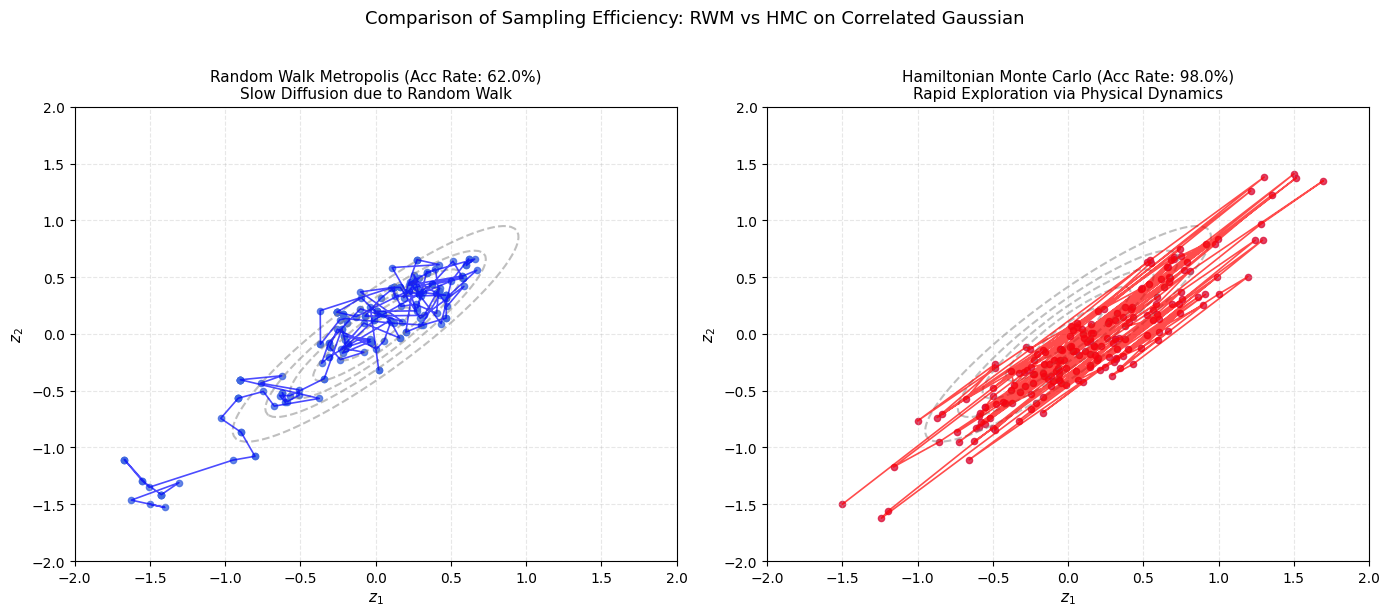

In [2]:
from common.sampling_utils import metropolis_hastings

# 1. ランダムウォーク・メトロポリス (RWM)
np.random.seed(42)
rwm_samples, rwm_acc = metropolis_hastings(
    lambda q: -potential_E(q),
    initial_state=[-1.5, -1.5],
    proposal_sampler=lambda q: q + np.random.normal(0, 0.2, size=2),
    n_samples=200
)

# 2. HMC
hmc_samples, hmc_acc = hamiltonian_monte_carlo(
    potential_E, grad_E,
    initial_state=[-1.5, -1.5],
    n_samples=200, step_size=0.08, n_leapfrog=12
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.0))

# RWM プロット
axes[0].contour(X, Y, dens, levels=5, colors='gray', linestyles='--', alpha=0.5)
axes[0].plot(rwm_samples[:, 0], rwm_samples[:, 1], 'b-', lw=1.2, alpha=0.7)
axes[0].scatter(rwm_samples[:, 0], rwm_samples[:, 1], color='royalblue', s=20, alpha=0.8)
axes[0].set_title(f'Random Walk Metropolis (Acc Rate: {np.mean(rwm_acc):.1%})\nSlow Diffusion due to Random Walk', fontsize=11)
axes[0].set_xlabel('$z_1$', fontsize=11); axes[0].set_ylabel('$z_2$', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)

# HMC プロット
axes[1].contour(X, Y, dens, levels=5, colors='gray', linestyles='--', alpha=0.5)
axes[1].plot(hmc_samples[:, 0], hmc_samples[:, 1], 'r-', lw=1.2, alpha=0.7)
axes[1].scatter(hmc_samples[:, 0], hmc_samples[:, 1], color='crimson', s=20, alpha=0.8)
axes[1].set_title(f'Hamiltonian Monte Carlo (Acc Rate: {hmc_acc:.1%})\nRapid Exploration via Physical Dynamics', fontsize=11)
axes[1].set_xlabel('$z_1$', fontsize=11); axes[1].set_ylabel('$z_2$', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Comparison of Sampling Efficiency: RWM vs HMC on Correlated Gaussian', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig11_hmc_vs_rwm_efficiency.png')
plt.show()